In [170]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [171]:
runs = pd.read_csv("./assets/runs.csv")
runs

,Start Time,Duration,Run ID,Name,Source Type,Source Name,User,Status,checkpoint.every_frames,checkpoint.save_final,...,sushigo.kind,sushigo.players,sushigo.seed,sushigo.checkpoint_schema,sushigo.preset,sushigo.repetition,sushigo.min_players,sushigo.max_players,sushigo.dense_players,sushigo.architecture
0,2026-08-01 18:06:05,2.1h,ff7c9e64890348edad17616988967f76,variable_encoder_2_4-r3,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_encoder_2_4,3,2,4,4,flex_encoder
1,2026-08-01 15:57:45,2.1h,a665630867144200adb56738eed146da,variable_encoder_2_4-r2,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_encoder_2_4,2,2,4,4,flex_encoder
2,2026-08-01 13:53:23,2.1h,420770657a844be6ab5e55e02edf3782,variable_encoder_2_4-r1,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_encoder_2_4,1,2,4,4,flex_encoder
3,2026-08-01 12:10:09,1.7h,982b1b91707d4b87abdfcc7aecfa5350,variable_2_4-r3,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_2_4,3,2,4,4,mlp
4,2026-08-01 10:24:12,1.8h,bb09607dedb34a45b4ea410e5fa000d0,variable_2_4-r2,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_2_4,2,2,4,4,mlp
5,2026-08-01 08:42:58,1.7h,bf23b43ba2e94b7d994bbae85dbabef5,variable_2_4-r1,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,variable_2_4,1,2,4,4,mlp
6,2026-08-01 06:56:25,1.8h,2ba4438df6cb4ff09780713b7eaa79ce,fixed_4p-r3,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,fixed_4p,3,4,4,4,mlp
7,2026-08-01 05:11:11,1.8h,2b5a56cc1b8e4d4399baaf67d2a47d95,fixed_4p-r2,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,fixed_4p,2,4,4,4,mlp
8,2026-08-01 03:24:15,1.8h,8c4f3137f08844a6a9bf39b13b8ce452,fixed_4p-r1,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,fixed_4p,1,4,4,4,mlp
9,2026-08-01 02:05:52,1.3h,e83fafd2d1f248479c486b5280206247,fixed_3p-r3,LOCAL,/home/thlamz/data_harvesting/projects/sushigo/...,thlamz,FINISHED,500000,True,...,training,NaN,NaN,1,fixed_3p,3,3,3,3,mlp


In [172]:
# Process durations into floats (1.3h -> 1.3)
runs['Duration'] = runs['Duration'].str.replace('h', '').astype(float)
runs['Duration']

0     2.1
1     2.1
2     2.1
3     1.7
4     1.8
5     1.7
6     1.8
7     1.8
8     1.8
9     1.3
10    1.3
11    1.3
12    1.3
13    1.3
14    1.3
Name: Duration, dtype: float64

In [173]:
# Consistent naming for models
name_mapping = {
  'fixed_2p': 'MLP 2P',
  'fixed_3p': 'MLP 3P',
  'fixed_4p': 'MLP 4P',
  'variable_2_4': 'MLP Variable-Cardinality',
  'variable_encoder_2_4': 'Flex Encoder'
}

runs['model'] = runs['sushigo.preset'].map(name_mapping)

runs['model']

0                 Flex Encoder
1                 Flex Encoder
2                 Flex Encoder
3     MLP Variable-Cardinality
4     MLP Variable-Cardinality
5     MLP Variable-Cardinality
6                       MLP 4P
7                       MLP 4P
8                       MLP 4P
9                       MLP 3P
10                      MLP 3P
11                      MLP 3P
12                      MLP 2P
13                      MLP 2P
14                      MLP 2P
Name: model, dtype: object

Text(0, 0.5, 'Average Training Time (hours)')

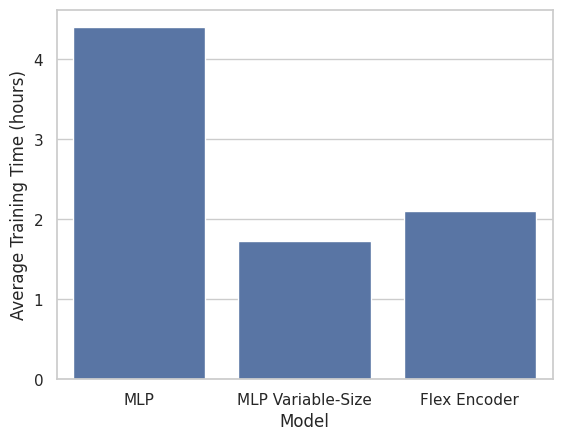

In [174]:
# Comparing durations by model

# For this figure, we sum the durations of all variations of the MLP (fixed_2p, fixed_3p, fixed_4p) into a single "MLP" category. The other two models are kept separate.
durations = runs.groupby(['sushigo.preset'])['Duration'].mean().reset_index()

agg_name_mapping = {
  'fixed_2p': 'MLP',
  'fixed_3p': 'MLP',
  'fixed_4p': 'MLP',
  'variable_2_4': 'MLP Variable-Size',
  'variable_encoder_2_4': 'Flex Encoder'
}
durations['model'] = durations['sushigo.preset'].map(agg_name_mapping)

# Plotting the durations
sns.barplot(x='model', y='Duration', data=durations, estimator='sum', errorbar=None)

plt.xlabel('Model')
plt.ylabel('Average Training Time (hours)')

# League Analysis

In [175]:

frames = []
for player_count in (2, 3, 4):
    path = f"./assets/matches_{player_count}p.csv"
    data = pd.read_csv(path)
    data["player_count"] = player_count
    frames.append(data)

df = pd.concat(frames, ignore_index=True)

def split_pipe(value):
    return str(value).split("|")


def pipe_ints(value):
    return [int(part) for part in split_pipe(value)]


def mean_pipe_ints(value):
    values = pipe_ints(value)
    return sum(values) / len(values)

df = df.reset_index(drop=True).copy()

# "opponents" contains one pipe-separated label per opponent.
df["n_players"] = df["opponents"].fillna("").str.count(r"\|") + 2

df["match_id"] = (
    "match_"
    + df["game"].astype(int).astype(str).str.zfill(6)
)

df["matchup_id"] = (
    df["n_players"].astype(str)
    + "p_matchup_"
    + df["matchup"].astype(int).astype(str).str.zfill(4)
)

new_columns = [
    "opponent_competitors",
    "opponent_run_ids",
    "opponent_presets",
    "opponent_repetitions",
    "opponent_points_all",
    "opponent_puddings",
    # Legacy convenience fields: first opponent by seat order.
    "opponent_competitor",
    "opponent_repetition",
    "opponent_points",
    "opponent_pudding",
]

for column in new_columns:
    df[column] = None

for (_, _), indexes in df.groupby(
    ["n_players", "game"], sort=False
).groups.items():
    game = df.loc[indexes].sort_values("seat")

    expected_players = int(game["n_players"].iloc[0])
    if len(game) != expected_players:
        raise ValueError(
            f"Game {game['game'].iloc[0]} has {len(game)} rows; "
            f"expected {expected_players}."
        )

    for row_index in game.index:
        opponents = game.drop(index=row_index).sort_values("seat")

        df.at[row_index, "opponent_competitors"] = "|".join(
            opponents["competitor"].astype(str)
        )
        df.at[row_index, "opponent_run_ids"] = "|".join(
            opponents["run_id"].astype(str)
        )
        df.at[row_index, "opponent_presets"] = "|".join(
            opponents["preset"].astype(str)
        )
        df.at[row_index, "opponent_repetitions"] = "|".join(
            opponents["repetition"].astype(str)
        )
        df.at[row_index, "opponent_points_all"] = "|".join(
            opponents["points"].astype(str)
        )
        df.at[row_index, "opponent_puddings"] = "|".join(
            opponents["pudding"].astype(str)
        )

        first = opponents.iloc[0]
        df.at[row_index, "opponent_competitor"] = first["competitor"]
        df.at[row_index, "opponent_repetition"] = first["repetition"]
        df.at[row_index, "opponent_points"] = first["points"]
        df.at[row_index, "opponent_pudding"] = first["pudding"]

league_mapping = {
}

for repetition in [1, 2, 3]:
    for model, value in agg_name_mapping.items():
        league_mapping[f"{model}/repetition_{repetition}"] = value

    league_mapping[f"random/repetition_{repetition}"] = "Random"

def average_rank_from_points(points, opponent_points_all):
    table_points = [int(points), *pipe_ints(opponent_points_all)]
    higher_scores = sum(score > points for score in table_points)
    tied_scores = sum(score == points for score in table_points)
    return higher_scores + (tied_scores + 1) / 2

df["competitor_label"] = df["competitor"].map(league_mapping)
df["opponent_labels"] = df["opponents"].apply(
    lambda names: [league_mapping[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["average_rank"] = df.apply(
    lambda row: average_rank_from_points(row["points"], row["opponent_points_all"]), axis=1
)
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"


In [176]:
model_order = [
    "MLP",
    "MLP Variable-Size",
    "Flex Encoder",
]

In [177]:
df

,matchup,game,competitor,run_id,preset,repetition,seat,points,pudding,outcome,...,opponent_repetition,opponent_points,opponent_pudding,competitor_label,opponent_labels,opponent_mean_points,point_margin,average_rank,won,player_count_label
0,1,1,fixed_2p/repetition_1,211a23690c7249b59eee5027400e397e,fixed_2p,1,0,56,3,loss,...,1,60,4,MLP,[MLP Variable-Size],60.000000,-4.000000,2.0,False,2p
1,1,1,variable_2_4/repetition_1,bf23b43ba2e94b7d994bbae85dbabef5,variable_2_4,1,1,60,4,win,...,1,56,3,MLP Variable-Size,[MLP],56.000000,4.000000,1.0,True,2p
2,1,2,fixed_2p/repetition_1,211a23690c7249b59eee5027400e397e,fixed_2p,1,0,49,3,loss,...,1,55,2,MLP,[MLP Variable-Size],55.000000,-6.000000,2.0,False,2p
3,1,2,variable_2_4/repetition_1,bf23b43ba2e94b7d994bbae85dbabef5,variable_2_4,1,1,55,2,win,...,1,49,3,MLP Variable-Size,[MLP],49.000000,6.000000,1.0,True,2p
4,1,3,fixed_2p/repetition_1,211a23690c7249b59eee5027400e397e,fixed_2p,1,0,57,5,win,...,1,50,3,MLP,[MLP Variable-Size],50.000000,7.000000,1.0,True,2p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34195,27,2699,variable_encoder_2_4/repetition_3,ff7c9e64890348edad17616988967f76,variable_encoder_2_4,3,3,43,3,win,...,1,18,0,Flex Encoder,"[Random, MLP, MLP Variable-Size]",29.666667,13.333333,1.0,True,4p
34196,27,2700,fixed_4p/repetition_3,2ba4438df6cb4ff09780713b7eaa79ce,fixed_4p,3,0,42,2,loss,...,3,43,2,MLP,"[Flex Encoder, MLP Variable-Size, Random]",36.333333,5.666667,3.0,False,4p
34197,27,2700,variable_encoder_2_4/repetition_3,ff7c9e64890348edad17616988967f76,variable_encoder_2_4,3,1,43,2,loss,...,3,42,2,Flex Encoder,"[MLP, MLP Variable-Size, Random]",36.000000,7.000000,2.0,False,4p
34198,27,2700,variable_2_4/repetition_3,982b1b91707d4b87abdfcc7aecfa5350,variable_2_4,3,2,51,4,win,...,3,42,2,MLP Variable-Size,"[MLP, Flex Encoder, Random]",33.333333,17.666667,1.0,True,4p


## Results Loaded

In [178]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,7200,3600,36
1,3,16200,5400,54
2,4,10800,2700,27


## Overall Results

In [193]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
          count=("won", "count")
      )
      .reset_index()
)
overall.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,games,wins,losses,ties,average_rank,raw_win_rate,mean_points,mean_margin,count
0,2,Flex Encoder,2100,1568,520,12,1.26,74.7%,58.38,+6.96,2100
1,2,MLP,2100,954,1131,15,1.53,45.4%,55.37,+0.79,2100
2,2,MLP Variable-Size,2100,1045,1043,12,1.50,49.8%,55.21,+1.73,2100
3,2,Random,900,13,886,1,1.99,1.4%,40.75,-22.09,900
4,3,Flex Encoder,4500,2365,2087,48,1.60,52.6%,48.59,+6.88,4500
5,3,MLP,4500,1704,2757,39,1.83,37.9%,46.70,+4.17,4500
6,3,MLP Variable-Size,4500,1264,3195,41,1.99,28.1%,45.40,+2.19,4500
7,3,Random,2700,3,2697,0,2.98,0.1%,27.51,-22.07,2700
8,4,Flex Encoder,2700,1127,1548,25,1.87,41.7%,41.73,+7.58,2700
9,4,MLP,2700,819,1851,30,2.02,30.3%,40.76,+6.29,2700


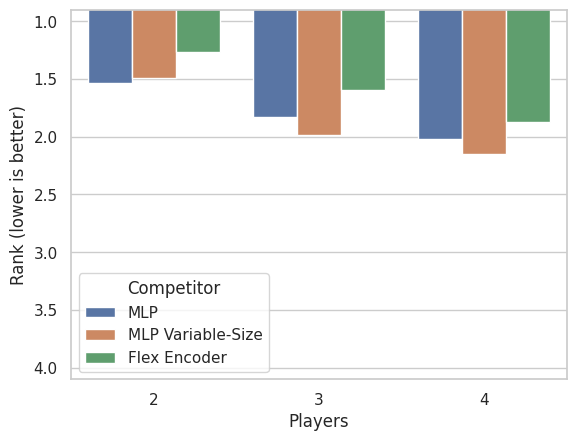

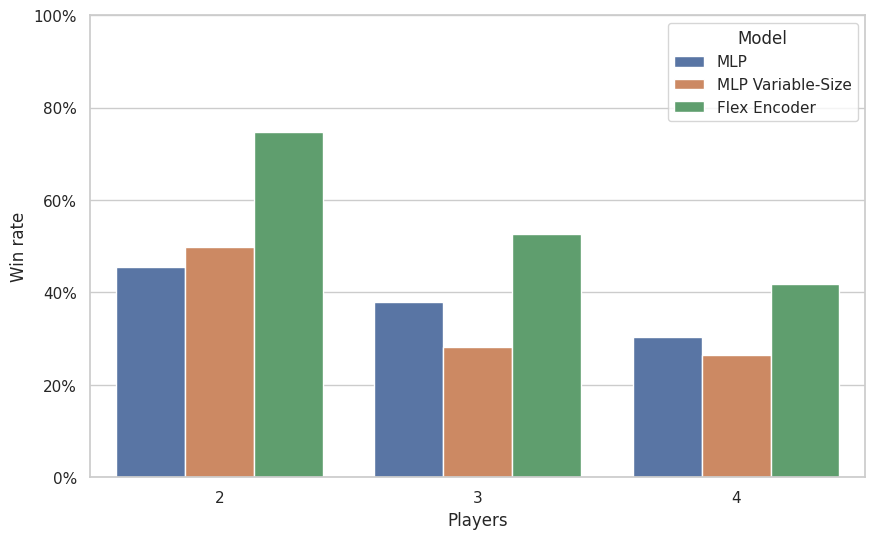

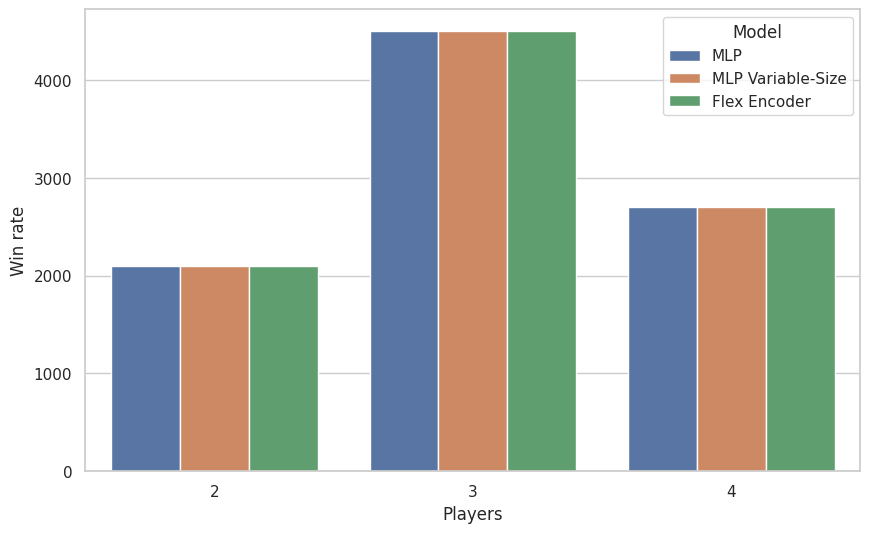

<Figure size 1000x600 with 0 Axes>

In [196]:
ax = plt.gca()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=overall,
    x="player_count",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=ax,
)

ax.set_xlabel("Players")
ax.set_ylabel("Rank (lower is better)")
ax.set_ylim(df["player_count"].max() + 0.1, 0.9)
ax.legend(title="Competitor")


ax = plt.gca()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=ax,
)

ax.set_xlabel("Players")
ax.set_ylabel("Win rate")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(title="Model")

ax = plt.gca()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=overall,
    x="player_count",
    y="count",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=ax,
)

ax.set_xlabel("Players")
ax.set_ylabel("Win rate")
ax.legend(title="Model")

## Matchup View

In [181]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label, opponent_points in zip(row.opponent_labels, pipe_ints(row.opponent_points_all)):
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "head_to_head_win": row.points > opponent_points,
            "head_to_head_tie": row.points == opponent_points,
            "head_to_head_margin": row.points - opponent_points,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("head_to_head_win", "size"),
          head_to_head_wins=("head_to_head_win", "sum"),
          head_to_head_ties=("head_to_head_tie", "sum"),
          head_to_head_losses=("head_to_head_win", lambda wins: (~wins).sum()),
          mean_head_to_head_margin=("head_to_head_margin", "mean"),
      )
      .reset_index()
)
matchup_summary["head_to_head_losses"] = matchup_summary["head_to_head_losses"] - matchup_summary["head_to_head_ties"]
matchup_summary["non_tie_games"] = matchup_summary["head_to_head_wins"] + matchup_summary["head_to_head_losses"]
matchup_summary["non_tie_head_to_head_win_rate"] = (
    matchup_summary["head_to_head_wins"] / matchup_summary["non_tie_games"]
)
matchup_summary.style.format({
    "non_tie_head_to_head_win_rate": "{:.1%}",
    "mean_head_to_head_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,head_to_head_wins,head_to_head_ties,head_to_head_losses,mean_head_to_head_margin,non_tie_games,non_tie_head_to_head_win_rate
0,2,Flex Encoder,MLP,900,613,41,246,+4.32,859,71.4%
1,2,Flex Encoder,MLP Variable-Size,900,600,32,268,+3.97,868,69.1%
2,2,Flex Encoder,Random,300,297,1,2,+23.81,299,99.3%
3,2,MLP,Flex Encoder,900,246,41,613,-4.32,859,28.6%
4,2,MLP,MLP Variable-Size,900,396,48,456,-1.06,852,46.5%
5,2,MLP,Random,300,294,1,5,+21.66,299,98.3%
6,2,MLP Variable-Size,Flex Encoder,900,268,32,600,-3.97,868,30.9%
7,2,MLP Variable-Size,MLP,900,456,48,396,+1.06,852,53.5%
8,2,MLP Variable-Size,Random,300,295,2,3,+20.81,298,99.0%
9,2,Random,Flex Encoder,300,2,1,297,-23.81,299,0.7%


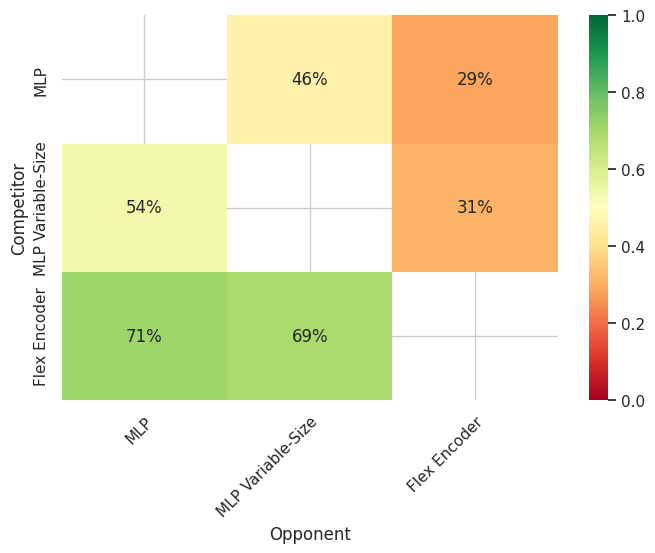

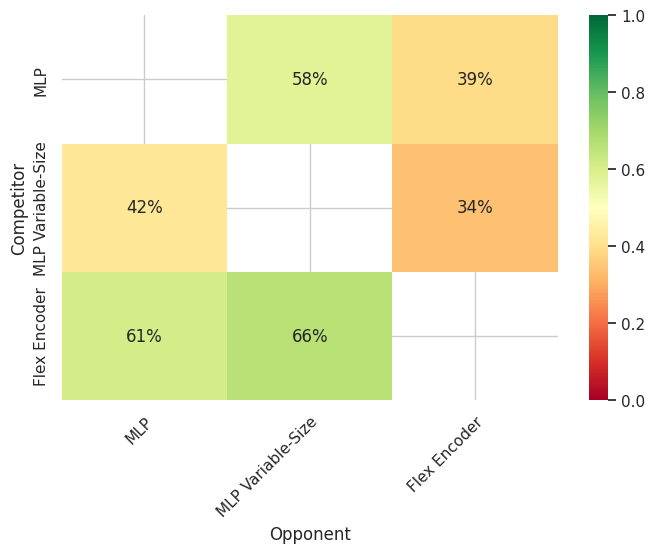

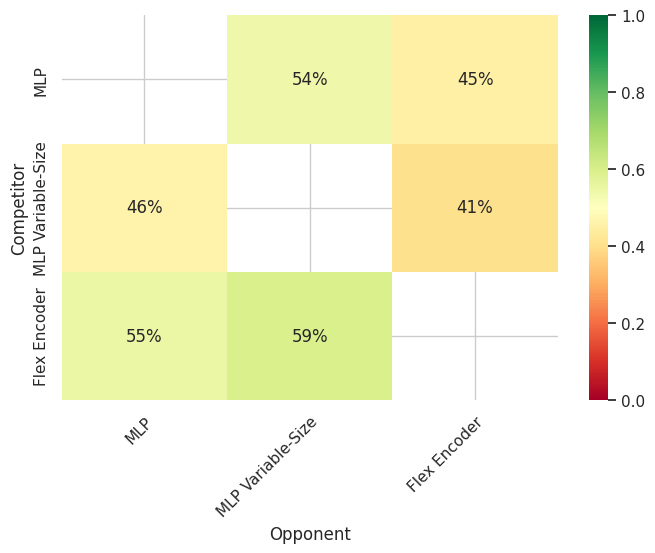

<Figure size 640x480 with 0 Axes>

In [189]:
for player_count in (2, 3, 4):
    player_models = [model for model in model_order]
    matrix = matchup_summary[matchup_summary["player_count"] == player_count].pivot(
        index="competitor_label", columns="opponent_label", values="non_tie_head_to_head_win_rate"
    ).reindex(index=player_models, columns=player_models)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)

    ax.set_xlabel("Opponent")
    # 45 degree X label
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_ylabel("Competitor")
    plt.show()
plt.tight_layout()

## Repetition Variance

In [183]:
repetition_results = (
    df.groupby(["player_count", "competitor_label", "repetition"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
      )
      .reset_index()
)

repetition_variance = (
    repetition_results.groupby(["player_count", "competitor_label"])
      .agg(
          repetitions=("repetition", "nunique"),
          mean_average_rank=("average_rank", "mean"),
          average_rank_variance=("average_rank", "var"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
repetition_variance[["average_rank_variance", "win_rate_variance"]] = repetition_variance[
    ["average_rank_variance", "win_rate_variance"]
].fillna(0)
repetition_variance.style.format({
    "mean_average_rank": "{:.2f}",
    "average_rank_variance": "{:.4f}",
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})


,player_count,competitor_label,repetitions,mean_average_rank,average_rank_variance,mean_win_rate,win_rate_variance
0,2,Flex Encoder,3,1.26,0.0009,74.7%,0.0008
1,2,MLP,3,1.53,0.0007,45.4%,0.0007
2,2,MLP Variable-Size,3,1.50,0.0001,49.8%,0.0002
3,2,Random,1,1.99,0.0000,1.4%,0.0000
4,3,Flex Encoder,3,1.60,0.0001,52.6%,0.0000
5,3,MLP,3,1.83,0.0011,37.9%,0.0003
6,3,MLP Variable-Size,3,1.99,0.0062,28.1%,0.0021
7,3,Random,1,2.98,0.0000,0.1%,0.0000
8,4,Flex Encoder,3,1.87,0.0007,41.7%,0.0000
9,4,MLP,3,2.02,0.0002,30.3%,0.0001


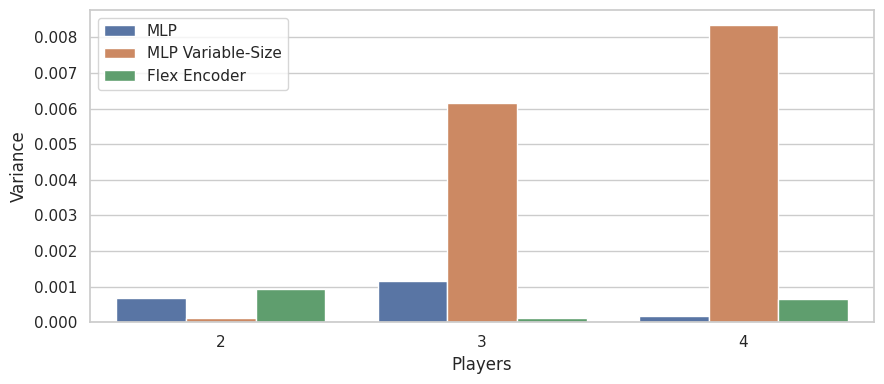

In [184]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=repetition_variance,
    x="player_count",
    y="average_rank_variance",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
)

plt.xlabel("Players")
plt.ylabel("Variance")
plt.legend(title="")
plt.tight_layout()


## Seat Effects

In [185]:
seat_results = (
    df.groupby(["player_count", "competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,seat,games,average_rank,raw_win_rate,mean_margin
0,2,Flex Encoder,0,1051,1.28,73.2%,+6.65
1,2,Flex Encoder,1,1049,1.25,76.2%,+7.27
2,2,MLP,0,1060,1.54,45.1%,+0.86
3,2,MLP,1,1040,1.53,45.8%,+0.71
4,2,MLP Variable-Size,0,1015,1.52,46.8%,+1.09
5,2,MLP Variable-Size,1,1085,1.47,52.5%,+2.32
6,2,Random,0,474,1.99,1.7%,-21.75
7,2,Random,1,426,1.99,1.2%,-22.47
8,3,Flex Encoder,0,1527,1.61,52.3%,+6.87
9,3,Flex Encoder,1,1473,1.60,52.2%,+6.76


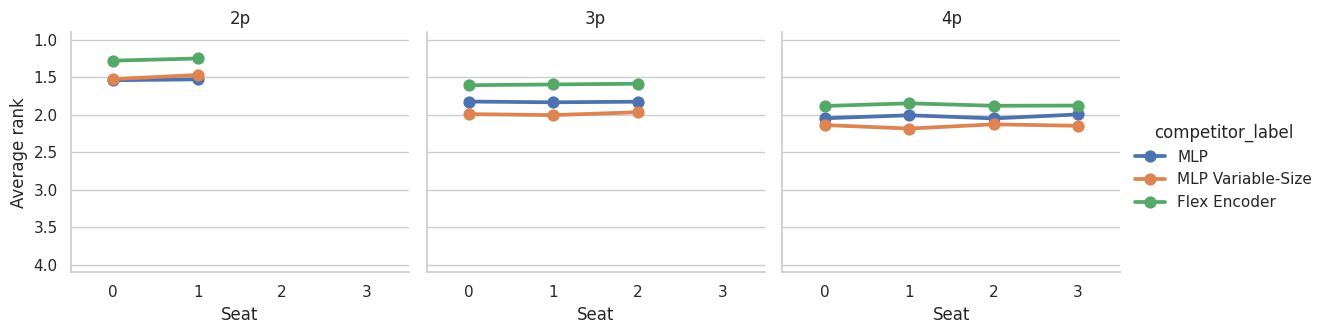

In [ ]:
grid = sns.catplot(
    data=seat_results,
    kind="point",
    x="seat",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    col="player_count",
    errorbar=None,
    height=3.5,
    aspect=1.1,
)
grid.set_axis_labels("Seat", "Average rank")

for ax in grid.axes.flat:
    ax.set_ylim(df["player_count"].max() + 0.1, 0.9)


## Training Metrics

In [187]:
from mlflow import MlflowClient


tracking_uri = "http://localhost:5000"
experiment_name = "sushigo"

checkpoint_aliases = {
    "fixed_2p": "MLP 2 Players",
    "fixed_3p": "MLP 3 Players",
    "fixed_4p": "MLP 4 Players",
    "variable_2_4": "MLP Variable-Cardinality",
    "variable_encoder_2_4": "Flex Encoder",
}

# MLflow metric name -> desired DataFrame column.
metric_columns = {
    "train/loss": "loss",
    "train/epsilon": "epsilon",
    "train/frames_per_second": "frames_per_second",
    "env/mean_turn_reward": "mean_turn_reward",
    "env/mean_episode_return": "mean_episode_return",
    "env/mean_final_score": "mean_final_score",
    "env/mean_winning_score": "mean_winning_score",
    "env/mean_score_spread": "mean_score_spread",
    "env/episodes_2p": "episodes_2p",
    "env/episodes_3p": "episodes_3p",
    "env/episodes_4p": "episodes_4p",
}

client = MlflowClient(tracking_uri=tracking_uri)

experiment = client.get_experiment_by_name(experiment_name)
if experiment is None:
    raise ValueError(f"MLflow experiment {experiment_name!r} was not found.")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=(
        "tags.`sushigo.kind` = 'training' "
        "AND attributes.status = 'FINISHED'"
    ),
    order_by=["attributes.start_time DESC"],
    max_results=5000,
)

training_metrics = []
seen_repetitions = set()

for run in runs:
    tags = run.data.tags
    preset = tags.get("sushigo.preset")
    repetition_text = tags.get("sushigo.repetition")

    if preset not in checkpoint_aliases or repetition_text is None:
        continue

    repetition = int(repetition_text)
    repetition_key = (preset, repetition)

    # If a repetition was rerun, use the newest finished run, matching league
    # discovery behavior.
    if repetition_key in seen_repetitions:
        continue

    # Ignore finished runs without the final league checkpoint.
    artifacts = client.list_artifacts(run.info.run_id, "policy")
    if not any(
        artifact.path == "policy/checkpoint.pt"
        for artifact in artifacts
    ):
        continue

    seen_repetitions.add(repetition_key)

    # Assemble all metric histories by training frame ("step").
    records_by_step = {}

    for metric_name, column_name in metric_columns.items():
        history = client.get_metric_history(run.info.run_id, metric_name)

        # Sorting ensures that if the same step was logged twice, the most
        # recent value wins.
        for point in sorted(
            history,
            key=lambda item: (item.step, item.timestamp),
        ):
            record = records_by_step.setdefault(
                point.step,
                {
                    "step": point.step,
                    "_timestamp": point.timestamp,
                },
            )
            record[column_name] = point.value
            record["_timestamp"] = max(
                record["_timestamp"],
                point.timestamp,
            )

    if not records_by_step:
        continue

    metrics = pd.DataFrame(records_by_step.values())
    metrics = metrics.sort_values("step").reset_index(drop=True)

    metrics["checkpoint"] = checkpoint_aliases[preset]
    metrics["preset"] = preset
    metrics["repetition"] = repetition
    metrics["run_id"] = run.info.run_id
    metrics["run_name"] = tags.get("mlflow.runName")

    # Approximate the old CSV elapsed-time column using MLflow timestamps.
    if run.info.start_time is not None:
        metrics["elapsed_seconds"] = (
            metrics["_timestamp"] - run.info.start_time
        ) / 1000
    else:
        metrics["elapsed_seconds"] = pd.NA

    # Sequential logging index. Prefer "step" for plots because it contains the
    # actual number of collected environment frames.
    metrics["iteration"] = range(len(metrics))
    metrics = metrics.drop(columns="_timestamp")

    training_metrics.append(metrics)


if not training_metrics:
    raise ValueError("No compatible completed Sushi Go training runs were found.")

training_df = (
    pd.concat(training_metrics, ignore_index=True)
    .sort_values(["checkpoint", "repetition", "step"])
    .reset_index(drop=True)
)

training_df["loss_smoothed"] = training_df.groupby(
    ["checkpoint", "repetition"]
)["loss"].transform(
    lambda values: values.rolling(100, min_periods=1).mean()
)

training_df["return_smoothed"] = training_df.groupby(
    ["checkpoint", "repetition"]
)["mean_episode_return"].transform(
    lambda values: values.rolling(100, min_periods=1).mean()
)

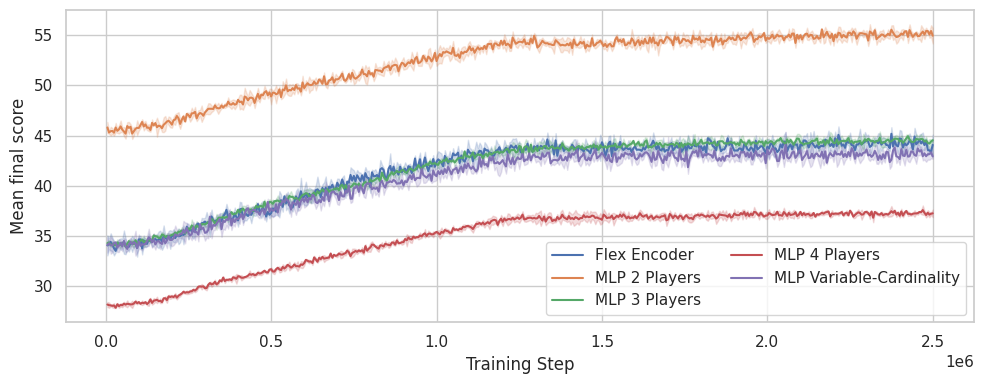

In [188]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="step", y="mean_final_score", hue="checkpoint", errorbar="sd")

plt.xlabel("Training Step")
plt.ylabel("Mean final score")
plt.legend(title="", ncol=2)
plt.tight_layout()